# End-to-End Example: Building Nutrition-Sensisitive Food Environment (N-FEI) Indicators with `nfei` package

This notebook provides a complete, step-by-step example of how to use the `nfei` package to construct food environment indicators from raw vendor-level data.

The Nutrition-Sensitive Food Environment Index (NFEI) is designed to quantify key aspects of food environments, including availability, diversity, density, and spatial accessibility. These indicators are essential for understanding how food environments influence dietary behavior, nutrition outcomes, and policy interventions.

Rather than presenting isolated functions, this notebook demonstrates how different components of the NFEI workflow fit together in practice. Starting from a minimally cleaned dataset, we apply validation, derive indicators, and prepare outputs that can be used for analysis, visualization, or index construction.

The example uses a small subset of real-world data to ensure that:
- the workflow remains realistic and reproducible
- each step reflects actual implementation logic
- users can clearly understand how to adapt the process to their own datasets

Throughout the notebook, we explain not only how each function is applied, but also why each step is necessary and how to interpret the outputs.

## What this example covers

This end-to-end workflow includes:

- Detect and correct coordinate outliers using a robust MAD-based approach.
- Compute vendor-level food diversity indicators.
- Compute produce color diversity indicators.
- Compute unhealthy beverage, snack, and total unhealthy food counts.
- Compute daily, weekly, and combined vendor availability.
- Estimate population covered by radius-based vendor mapping.
- Compute vendor density by population and land area.
- Aggregate food environment features within spatial buffers.
- Calculate nearest distances and spatial aggregations for enviromental exposure around a point.
- Scale indicators to a common interpretation range.

Each section builds on the previous step, forming a coherent pipeline for nutrition-sensitive food environment analysis.

## Load required packages including `nfei`

In [1]:
# Import required packages
import pandas as pd
import nfei

## Load sample data

We begin by loading a small sample dataset derived from a real food environment survey. The dataset contains vendor-level information, including geographic coordinates, food availability indicators, and contextual variables.

The data has undergone minimal preprocessing to retain realistic characteristics, including potential inconsistencies such as coordinate outliers. These issues are intentionally preserved so that the validation steps demonstrated in this notebook are meaningful.

In [2]:
# Import data
file_path = r"~\OneDrive - CGIAR\Documents\GitHub\nutrition-food-environment-index\data"
df = pd.read_csv(file_path + r"\sample_fe.csv")

df.head()

,survey_id,_latitude,_longitude,county,subcounty,ward,vendor_type,vendor_allday,hoursop_morning,hoursop_afternoon,...,mrenda_jute_mallow_color,pumpkin_leaves_color,spider_plant_sagaa_color,spinach_color,stinging_nettles_color,terere_amaranthus_color,african_lettuce_color,bitter_leaf_color,african_eggplant_color,vitex_color
0,BELI-COAR-AVOT-10011820,6.375696,2.464377,Littoral,Cotonou,Arrondissement 1,Ambulant/street hawkers/mobile,1,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BELI-COAR-AVOT-10011998,6.380834,2.474236,Littoral,Cotonou,Arrondissement 1,Stalls/Tabletop,0,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,BELI-COAR-AVOT-10041219,6.375614,2.466005,Littoral,Cotonou,Arrondissement 1,Kiosk,1,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,BELI-COAR-AVOT-10121823,6.373633,2.476751,Littoral,Cotonou,Arrondissement 1,Kiosk,1,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,BELI-COAR-AVOT-10141684,6.372367,2.470791,Littoral,Cotonou,Arrondissement 1,Stalls/Tabletop,0,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


> **Note**  
> This dataset is intentionally not fully cleaned. The goal of this notebook is to demonstrate how the `nfei` package functions can be used to transform raw or semi-processed data into analytically meaningful indicators.

> Each section includes a brief description of the columns used. This serves as a lightweight data dictionary to help users understand how the input data maps to the NFEI indicators.

## 1. Spatial Validation and Coordinate Correction

Spatial coordinates are central to food environment analysis because they determine where vendors are located and how they relate to households, markets, roads, or administrative boundaries. If a few latitude or longitude values are incorrectly recorded, they can distort distance calculations, buffer analysis, density estimates, and spatial aggregation.

In this step, we use the `fix_spatial_outliers()` function to detect and correct extreme coordinate values. The function applies the Median Absolute Deviation (MAD) method separately to latitude and longitude, then flags a record as a spatial outlier if either coordinate is unusually far from the central distribution of the data.

For this example, we use the Cotonou subset because it contains coordinate values that make the validation step meaningful.

Before correcting the data, we first inspect the coordinate columns. This helps confirm that latitude and longitude are numeric and gives a quick sense of the coordinate range before applying any correction.

In this section, the columns we are using include:

- `_latitude`: Geographic latitude of the vendor  
- `_longitude`: Geographic longitude of the vendor 

In [3]:
# Inspect raw coordinates
df[["_latitude", "_longitude"]].describe()

,_latitude,_longitude
count,1011.000000,1011.000000
mean,6.373962,2.465580
std,0.003636,0.017929
min,6.363304,2.388720
25%,6.371473,2.466005
50%,6.374152,2.470455
75%,6.377004,2.473269
max,6.382094,2.479796


We will now apply `fix_spatial_outliers()`.

In this example, we have set `show_plots=True` because this is a teaching example. The first plot shows the original coordinate distribution and highlights the detected outliers. The second plot shows the coordinate distribution after outlying points have been replaced with representative median values from the non-outlier observations.

In routine production workflows, users may set `show_plots=False` to avoid rendering plots repeatedly.

> **Note**  
>This function would run through the dataset, and if no outlier is detected, no changes will be made. In the plots, outliers will be specified as a red dot to let you know what exactly has been cleaned in the output dataset.

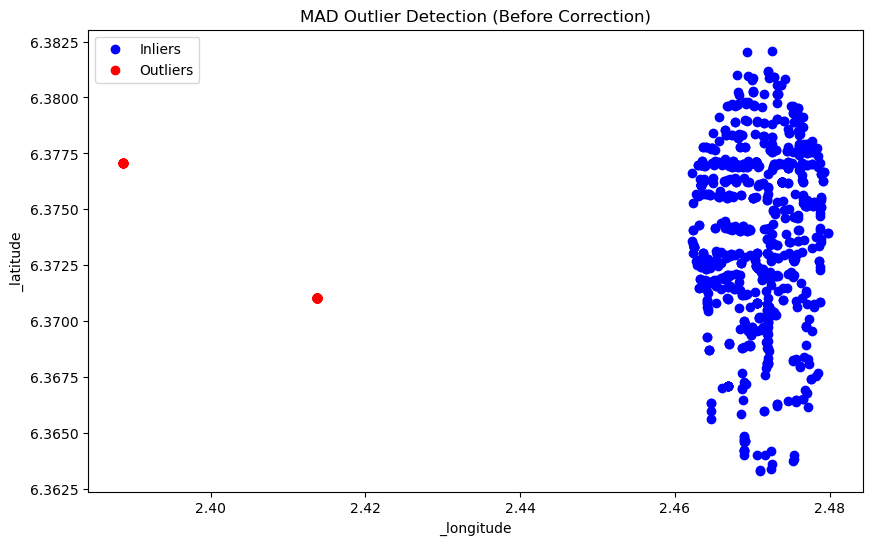

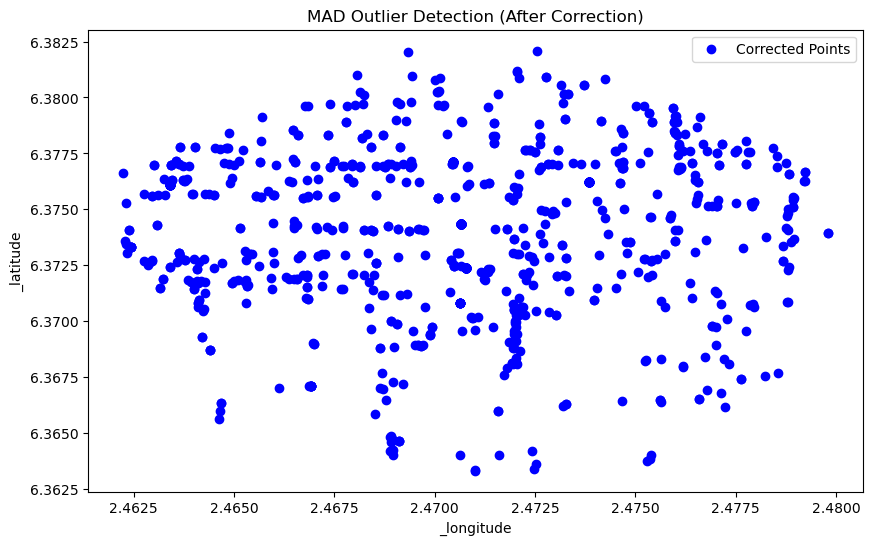

In [4]:
df_validated = nfei.fix_spatial_outliers(
    df=df,
    latitude="_latitude",
    longitude="_longitude",
    show_plots=True
)

The output is a copy of the input dataframe with corrected coordinate values. The correction does not drop any vendor records. Instead, outlying latitude and longitude values are replaced with median coordinate values calculated from the non-outlier observations. This preserves the record while reducing the risk that erroneous coordinates distort later spatial analysis.

## 2. Vendor availability

Vendor availability captures how consistently food sources are accessible to consumers. In the NFEI workflow, availability has two components: daily availability and weekly availability.

Daily availability reflects the time periods during the day when a vendor operates. Weekly availability reflects the number of days in the week when the vendor operates. These two components are then averaged to create an overall vendor availability score.

In the original survey data, time-of-day and day-of-week availability were stored as multiple-choice text fields. For this example, these responses have been transformed into binary indicator columns with clear prefixes (`hoursop_` and `daysop_`). This makes the package functions more flexible, because users can map their own dataset columns to the required time and day categories.

This naming convention improves clarity and avoids ambiguity when working with multiple types of variables in the same dataset. It also allows the `nfei` functions to remain flexible, since users explicitly map their dataset columns to the required time and day categories.

The following columns are used to compute vendor availability:

- `vendor_allday`: Indicates whether the vendor operates throughout the day  
- `hoursop_morning`: Availability during morning hours  
- `hoursop_afternoon`: Availability during afternoon hours  
- `hoursop_evening`: Availability during evening hours  
- `hoursop_night`: Availability during night hours  

- `vendor_allweek`: Indicates whether the vendor operates every day of the week  
- `daysop_monday`: Availability on Monday  
- `daysop_tuesday`: Availability on Tuesday  
- `daysop_wednesday`: Availability on Wednesday  
- `daysop_thursday`: Availability on Thursday  
- `daysop_friday`: Availability on Friday  
- `daysop_saturday`: Availability on Saturday  
- `daysop_sunday`: Availability on Sunday  

In [5]:
# define our dictionary for time columns
time_cols = {
    "morning": "hoursop_morning",
    "afternoon": "hoursop_afternoon",
    "evening": "hoursop_evening",
    "night": "hoursop_night",
}

# define our list for day columns
day_cols = [
    "daysop_monday",
    "daysop_tuesday",
    "daysop_wednesday",
    "daysop_thursday",
    "daysop_friday",
    "daysop_saturday",
    "daysop_sunday",
]

We first calculate daily availability. The default NFEI weights assign 30% each to morning, afternoon, and evening availability, and 10% to night availability. These weights reflect the assumption that most food purchasing activity occurs during the main daytime periods, while night-time operation contributes a smaller share.

We set `all_day_col="vendor_allday"` so that vendors marked as operating all day receive a daily availability score of 100, even if individual time-period columns are not separately marked.

In [6]:
df_validated = nfei.add_daily_availability(
    df=df_validated,
    time_cols=time_cols,
    all_day_col="vendor_allday",
    missing_policy="raise",
)

Next, we calculate weekly availability. This is computed as the number of available days divided by seven, multiplied by 100. We set `all_week_col="vendor_allweek"` so that vendors marked as operating all week receive a weekly availability score of 100.

In [7]:
df_validated = nfei.add_weekly_availability(
    df=df_validated,
    day_cols=day_cols,
    all_week_col="vendor_allweek",
    round_result=True,
    missing_policy="raise",
)

Finally, we combine the daily and weekly components into a single vendor availability score. This score is the average of daily availability and weekly availability, measured on a 0 to 100 percentage scale.

In [8]:
df_validated = nfei.add_vendor_availability(df_validated)

df_validated[
    [
        "survey_id",
        "perc_daily_avail",
        "perc_weekly_avail",
        "perc_vendor_avail",
    ]
].head()

,survey_id,perc_daily_avail,perc_weekly_avail,perc_vendor_avail
0,BELI-COAR-AVOT-10011820,100,100,100.0
1,BELI-COAR-AVOT-10011998,60,100,80.0
2,BELI-COAR-AVOT-10041219,100,85,92.5
3,BELI-COAR-AVOT-10121823,100,85,92.5
4,BELI-COAR-AVOT-10141684,30,100,65.0


The output adds three availability indicators to the dataset:

- `perc_daily_avail`: estimated percentage availability within a typical day
- `perc_weekly_avail`: estimated percentage availability across the week
- `perc_vendor_avail`: combined vendor availability score

Higher values indicate that a vendor is more consistently accessible to consumers over time.

> **Note**  
> We have used missing_policy="raise" in the notebook. This is the default because it forces users to notice missing availability values instead of silently treating them as zero. The function allows "fill" and "ignore", but for a reproducible analytical workflow, "raise" is safer unless the user has a clear reason to impute missing values.

## 3. Produce color diversity

Produce color diversity captures variation in the types of fruits and vegetables available from vendors. In nutrition-sensitive food environment analysis, color diversity is useful because produce color groups often reflect different nutrient profiles and can complement food-group diversity indicators.

In the original survey structure, produce color information was stored across several repeat-group sheets for fruits and vegetables. During sample dataset preparation, these sheets were merged into the main vendor dataset using `survey_id`.

Here, we use `add_produce_color_diversity()` to scan the selected produce color columns and identify whether each of the six NFEI color groups is present. The final score counts the number of distinct color groups available for each vendor.

This section uses produce color columns from fruit and vegetable modules. Each column records the color group associated with a specific produce item where that item was available.

Examples include:

- `apple_color`: Color group recorded for apples
- `avocado_color`: Color group recorded for avocado
- `tomato_color`: Color group recorded for tomato
- `carrots_color`: Color group recorded for carrots
- `spinach_color`: Color group recorded for spinach

The function scans across all selected color columns and checks whether any of the six NFEI produce color groups are present.

The default color group matches what is already defined in the function. This can be refined to match the users list accordingly.

DEFAULT_COLOR_GROUPS = [
    "White_Brown",
    "Yellow_Orange",
    "Green_other",
    "Dark_leafy_green",
    "Red",
    "Purple_Blue"
]

However, for the sake of our implementation, we will also define a new one, using a different list name for clarity.

We will start by defining all the color columns into a list to be used in the `add_produce_color_diversity()` function.

In [9]:
# Select few color columns to display for the example to show the structure of the dataset used
df_validated[[
    "survey_id",
    "tomato_color",
    "onions_color"]].head()

,survey_id,tomato_color,onions_color
0,BELI-COAR-AVOT-10011820,NaN,NaN
1,BELI-COAR-AVOT-10011998,Yellow_Orange,White_Brown
2,BELI-COAR-AVOT-10041219,NaN,NaN
3,BELI-COAR-AVOT-10121823,NaN,NaN
4,BELI-COAR-AVOT-10141684,NaN,NaN


In [10]:
# Define the list of color columns to be used for calculating the produce color diversity score
color_cols = [
    # other fruits
    "apple_color",
    "avocado_color",
    "cashew_color",
    "ripe_banana_color",
    "oranges_color",
    "tamarind_color",
    "jackfruit_color",
    "watermelon_color",
    "pineapple_color",
    "pears_color",
    "lemon_color",
    "lime_color",
    "guava_color",
    "grapes_color",
    "kiwi_color",
    "pear_color",
    "plums_color",
    "tangerine_color",
    "strawberries_color",
    "roselle_color",
    "mirabelle_color",
    "grapefruit_color",
    "rhonium_color",

    # other vegetables
    "artichoke_color",
    "asparagus_color",
    "beet_roots_color",
    "broccoli_color",
    "cabbage_color",
    "cauliflower_color",
    "cucumber_color",
    "eggplant_color",
    "tomato_color",
    "green_sweet_capsicum_color",
    "mushrooms_color",
    "onions_color",
    "green_beans_color",
    "french_beans_color",
    "okra_color",
    "zucchini_color",
    "taro_leaves_color",
    "onion_leaves_color",
    "cassava_leaves_color",
    "potato_leaves_color",
    "daha_leaves_color",

    # vitamin A-rich fruits and vegetables
    "butternut_color",
    "carrots_color",
    "fleshed_squash_color",
    "fleshed_swt_potato_color",
    "pumpkin_color",
    "red_sweet_capsicum_color",
    "ripe_mango_color",
    "ripe_papaya_color",
    "ripe_passion_fruit_color",
    "yellow_orange_cassava_color",

    # dark green leafy vegetables
    "african_night_shade_managu_color",
    "african_spinach_nderema_color",
    "africa_kales_kanzira_color",
    "cowpea_leaves_kunde_color",
    "crotalaria_slender_leaves_color",
    "kales_sukuma_wiki_color",
    "mrenda_jute_mallow_color",
    "pumpkin_leaves_color",
    "spider_plant_sagaa_color",
    "spinach_color",
    "stinging_nettles_color",
    "terere_amaranthus_color",
    "african_lettuce_color",
    "bitter_leaf_color",
    "african_eggplant_color",
    "vitex_color",
]

# Define the list of color groups to be used for calculating the produce color diversity score
DEFAULT_COLOR_GROUPS = [
    "White_Brown",
    "Yellow_Orange",
    "Green_other",
    "Dark_leafy_green",
    "Red",
    "Purple_Blue"
]

In [11]:
df_validated = nfei.add_produce_color_diversity(
    df=df_validated,
    color_cols=color_cols,
    color_groups=DEFAULT_COLOR_GROUPS,
    output_col="procolor_diversity",
    include_color_flags=True,
)

df_validated[
    [
        "survey_id",
        "White_Brown_color",
        "Yellow_Orange_color",
        "Green_other_color",
        "Dark_leafy_green_color",
        "Red_color",
        "Purple_Blue_color",
        "procolor_diversity",
    ]
].head()

,survey_id,White_Brown_color,Yellow_Orange_color,Green_other_color,Dark_leafy_green_color,Red_color,Purple_Blue_color,procolor_diversity
0,BELI-COAR-AVOT-10011820,0,0,0,0,0,0,0
1,BELI-COAR-AVOT-10011998,1,1,0,0,0,0,2
2,BELI-COAR-AVOT-10041219,0,0,0,0,0,0,0
3,BELI-COAR-AVOT-10121823,0,0,0,0,0,0,0
4,BELI-COAR-AVOT-10141684,0,0,0,0,0,0,0


The output creates one binary column for each produce color group and an overall color diversity score.

Each binary color column equals 1 if that color group appears in at least one of the selected produce color fields for the vendor. The `overall_color` column is the sum of these binary indicators, so it ranges from 0 to 6.

A higher value means the vendor offers produce spanning more color groups.

## 4. Food diversity and unhealthy food availability

Food diversity indicators summarize the range of food groups available from vendors. In this example, we calculate the Market-Level Diversity Score (MLDS), which counts how many of the 10 required food groups are available for each vendor.

We also calculate an unhealthy food count using selected beverage and snack items. This indicator captures the availability of foods and drinks that may need to be interpreted differently from healthy diversity indicators. In later scaling steps, this type of indicator is typically inverted so that higher scaled values represent healthier food environments.

For MLDS, the following vendor-level food availability columns are used:

- `grains`: Availability of grains  
- `roots_tubers`: Availability of roots and tubers  
- `legumes_pulses`: Availability of legumes and pulses  
- `nuts_seeds`: Availability of nuts and seeds  
- `dairy`: Availability of dairy products  
- `flesh_meat`: Availability of flesh meat  
- `organ_meat`: Availability of organ meat  
- `fish`: Availability of fish  
- `egg`: Availability of eggs  
- `dark_green_veg`: Availability of dark green leafy vegetables  
- `vita_rich_fruits`: Availability of vitamin A-rich fruits and vegetables  
- `other_veg`: Availability of other vegetables  
- `other_fruits`: Availability of other fruits  

For unhealthy food availability, selected beverage and snack item columns are loaded from separate sample files from the same survey.

### Code for healthy foods

In [12]:
# Implement the market-level diversity score calculation

# Define the dictionary for food group columns to be used for calculating the market-level diversity score
food_group_cols = {
    "grains_roots_tubers": ["grains", "roots_tubers"],
    "legumes_pulses": "legumes_pulses",
    "nuts_seeds": "nuts_seeds",
    "dairy": "dairy",
    "meat_poultry_fish": ["flesh_meat", "organ_meat", "fish"],
    "eggs": "egg",
    "dark_green_leafy_vegetables": "dark_green_veg",
    "vitamin_a_rich_fruits": "vita_rich_fruits",
    "other_vegetables": "other_veg",
    "other_fruits": "other_fruits",
}

# Calculate the market-level diversity score
df_validated = nfei.add_market_level_diversity_score(
    df=df_validated,
    food_group_cols=food_group_cols,
    output_col="mlds",
)

df_validated[["survey_id", "mlds"]].head()

,survey_id,mlds
0,BELI-COAR-AVOT-10011820,2
1,BELI-COAR-AVOT-10011998,1
2,BELI-COAR-AVOT-10041219,4
3,BELI-COAR-AVOT-10121823,0
4,BELI-COAR-AVOT-10141684,0


The `mlds` column ranges from 0 to 10. Each point represents one required food group available from the vendor. A higher score indicates that the vendor offers a wider range of food groups.

### Code for unhealthy foods

In [13]:
# Implement the unhealthy food count calculation
# Load the beverage and snacks data separately
beverage_df = pd.read_csv(file_path + r"\sample_condbev.csv")
snack_df = pd.read_csv(file_path + r"\sample_snacks.csv")

# Define the list of beverage and snack columns to be used for calculating the unhealthy food count
beverage_cols = [
    "alcoholic_beverages",
    "energy_drinks",
    "sweetened_beverages_fruit_juices",
]

snack_cols = [
    "biscuits",
    "canned_fruits",
    "cakes_pastries",
    "candies",
    "cookies",
    "chocolates",
    "ice_cream",
    "pie",
    "sweets",
]

# Calculate the unhealthy food count
unhealthy_df = nfei.add_unhealthy_food_count(
    beverage_df=beverage_df,
    snack_df=snack_df,
    beverage_cols=beverage_cols,
    snack_cols=snack_cols,
    id_col="survey_id",
)

unhealthy_df.head()

,survey_id,unhealthy_bev_count,unhealthy_snack_count,unhealthy_food_count
0,BEAT-ABGO-PARA-19481280,3,9,12
1,BELI-COAR-AVOT-10011998,0,0,0
2,BELI-COAR-AVOT-10041219,3,3,6
3,BELI-COAR-AVOT-10121823,2,1,3
4,BELI-COAR-AVOT-10181087,1,2,3


In [14]:
# Merge the unhealthy food count back to the main dataframe
df_validated = df_validated.merge(
    unhealthy_df,
    on="survey_id",
    how="left"
)

# Replace NA in these columns with 0 since NA means that there were no unhealthy beverages or snacks available in the market and convert to integer
fill_cols = ["unhealthy_bev_count", "unhealthy_snack_count", "unhealthy_food_count"]
for col in fill_cols:
    df_validated[col] = df_validated[col].fillna(0).astype(int)

# Display the final dataframe with the new columns added
df_validated[
    [
        "survey_id",
        "mlds",
        "unhealthy_bev_count",
        "unhealthy_snack_count",
        "unhealthy_food_count",
    ]
].head()

,survey_id,mlds,unhealthy_bev_count,unhealthy_snack_count,unhealthy_food_count
0,BELI-COAR-AVOT-10011820,2,0,0,0
1,BELI-COAR-AVOT-10011998,1,0,0,0
2,BELI-COAR-AVOT-10041219,4,3,3,6
3,BELI-COAR-AVOT-10121823,0,2,1,3
4,BELI-COAR-AVOT-10141684,0,0,0,0


The unhealthy food output contains separate counts for selected beverages and snacks, plus a combined `unhealthy_food_count`. Higher values indicate greater availability of selected unhealthy items. This indicator is useful, but it should be interpreted differently from MLDS because more unhealthy items do not represent a healthier food environment.

## 5. Vendor density

Vendor density indicators describe the concentration of vendors relative to population and land area. These indicators are useful for understanding whether food sources are sparse, concentrated, or widely available within a defined area.

In some datasets, population and land area are already available for administrative units such as wards, subcounties, or municipalities. In this example, the vendor mapping was conducted **within a fixed 1 km radius**. We therefore first estimate the mapped area and the population covered by that radius-based mapped area, then use those values to calculate vendor density.

Columns used in this section include:

- `subcounty`: Geographic grouping used for density calculation  
- `vendor_type`: Vendor category used to calculate vendor-type-specific counts  
- `Population`: Estimated population covered by the mapped survey area  
- `Land_area_sqkm`: Estimated land area covered by the mapped survey area  

### Estimate mapped area and population

The `estimate_population_from_radius` function estimates the circular mapped area using the radius and then approximates the population covered by applying the population density of the larger administrative area.

This assumes that population is evenly distributed across the larger area, so the result should be treated as an estimated denominator rather than an exact population count.

In this regard;

- cotonou's population now stands at 738,444 according to (https://worldpopulationreview.com/world-cities/cotonou-population) with an annual growth rate of 2.26% with an area of 79SqKm. Survey was conducted in 1km radius

In [15]:
# Calculate the population density of Cotonou using the estimate_population_from_radius function
cotonou_area = nfei.estimate_population_from_radius(
    population=738444,
    land_area_sqkm=79,
    radius_km=1,
)

cotonou_area

{'population_density_per_sqkm': 9347.39240506329,
 'area_covered_sqkm': 3.14,
 'estimated_population': 29366.0}

### Add denominator column to dataframe

In [16]:
# Add the land area and population of Cotonou to the main dataframe
df_validated["Land_area_sqkm"] = cotonou_area["area_covered_sqkm"]
df_validated["Population"] = cotonou_area["estimated_population"]

### Apply vendor density function

In [17]:
df_validated = nfei.add_vendor_density(
    df=df_validated,
    group_col="subcounty",
    vendor_type_col="vendor_type",
    population_col="Population",
    land_area_col="Land_area_sqkm",
    rate_per=1000, #optional, default is None
    rate_col="vendor_type_per_1000_people", # optional, only needed if rate_per is specified
)

df_validated[
    [
        "survey_id",
        "subcounty",
        "vendor_type",
        "vendor_type_pop",
        "vendor_type_per_pop",
        "vendor_type_per_1000_people",
        "vendor_type_per_sqkm",
    ]
].head()

,survey_id,subcounty,vendor_type,vendor_type_pop,vendor_type_per_pop,vendor_type_per_1000_people,vendor_type_per_sqkm
0,BELI-COAR-AVOT-10011820,Cotonou,Ambulant/street hawkers/mobile,155,0.005278,5.278213,49.363057
1,BELI-COAR-AVOT-10011998,Cotonou,Stalls/Tabletop,306,0.010420,10.420214,97.452229
2,BELI-COAR-AVOT-10041219,Cotonou,Kiosk,363,0.012361,12.361234,115.605096
3,BELI-COAR-AVOT-10121823,Cotonou,Kiosk,363,0.012361,12.361234,115.605096
4,BELI-COAR-AVOT-10141684,Cotonou,Stalls/Tabletop,306,0.010420,10.420214,97.452229


The output adds vendor-type-specific density indicators to each vendor record.

- `vendor_type_pop` counts vendors of the same type within the same geographic group.
- `vendor_type_per_pop` expresses that count relative to the population denominator.
- `vendor_type_per_1000_people` presents the population-based density as a more interpretable rate based on the rate defined by user - in this case per 1000. However this is optional.
- `vendor_type_per_sqkm` expresses the same vendor count relative to mapped land area.

Because this example uses a 1 km radius-based mapped area, the population and land area denominators are estimated before density calculation. If administrative population and land area are already available, users can provide those columns directly.

## 6. Access to infrastructure

Food environment conditions are influenced not only by the foods sold by vendors, but also by nearby infrastructure. Water points, sanitation facilities, health facilities, and natural food sources can shape the quality, safety, and usability of food environments.

In this section, we estimate vendor access to selected infrastructure using buffer-based spatial aggregation. For each vendor, we count how many infrastructure points fall within a 500 metre buffer. We then convert these counts into binary access indicators.

Vendor data:

- `_longitude`: Vendor longitude  
- `_latitude`: Vendor latitude  

Infrastructure data:

- `_longitude`: Infrastructure longitude  
- `_latitude`: Infrastructure latitude  
- `subcounty`: Location of the infrastructure point  
- `infras`: Infrastructure category used for access indicators  

In [18]:
df_infras = pd.read_csv(file_path + r"\sample_infras.csv")
df_infras.head()

,_longitude,_latitude,subcounty,infras
0,2.473834,6.376230,Cotonou,billboard
1,2.470455,6.377094,Cotonou,public_toilet
2,2.470454,6.375523,Cotonou,school
3,2.470455,6.377094,Cotonou,billboard
4,2.475983,6.378983,Cotonou,billboard


### Preparing the infrastructure dataset

The infrastructure data is stored separately from the vendor dataset. Each row contains coordinates and a multiple select field describing one or more infrastructure types found at that location.

Before estimating access, we need to reshape this dataset so that each row represents one infrastructure point and one infrastructure category. This is necessary because the proximity function counts nearby rows. If multiple infrastructure types remain stored in one comma-separated cell, they cannot be grouped or counted cleanly.

Since the `infras` column may contain infrastructure names with underscores and comma-separated values, we  will first standardize the text by replacing underscores with spaces, converting names to title case, and splitting multiple infrastructure types into lists.

In [19]:
# Clean the infrastructure column by replacing underscores with spaces, converting to title case, and splitting the comma-separated values into lists
df_infras["infras"] = (
    df_infras["infras"]
    .str.replace("_", " ")
    .str.title()
    .str.split(",")
)

After splitting the comma-separated values, we use `explode()` so that each infrastructure type becomes its own row. This gives us a tidy structure where each row is a single infrastructure observation.

In [20]:
# explode the infras column to have one row per infrastructure type
df_infras = df_infras.explode("infras", ignore_index=True)

# Strip any leading or trailing whitespace from the infrastructure types
df_infras["infras"] = df_infras["infras"].str.strip()

df_infras.head()

,_longitude,_latitude,subcounty,infras
0,2.473834,6.376230,Cotonou,Billboard
1,2.470455,6.377094,Cotonou,Public Toilet
2,2.470454,6.375523,Cotonou,School
3,2.470455,6.377094,Cotonou,Billboard
4,2.475983,6.378983,Cotonou,Billboard


In [21]:
# check the unique infrastructure types available in the dataset
df_infras["infras"].unique()

array(['Billboard', 'Public Toilet', 'School', 'Fruit Tree', 'Hospital',
       'Waste Mgt'], dtype=object)

Next, we keep only the infrastructure types that are relevant for the access indicators in this example. These are then grouped into broader categories that are easier to interpret analytically.

In [22]:
import numpy as np

# Filter the DataFrame to include only the specified infrastructure types
df_infras = df_infras[
    df_infras["infras"].isin(
        [
            "Hospital",
            "Health Post",
            "Clinic Pharm",
            "Handwash",
            "Public Water",
            "Public Toilet",
            "Veg Garden",
            "Farm",
            "Fruit Tree",
        ]
    )
]

# Create a new column 'infras_group' based on the specified conditions
conditions = [
    df_infras["infras"].isin(["Hospital", "Health Post", "Clinic Pharm"]),
    df_infras["infras"].isin(["Handwash", "Public Water"]),
    df_infras["infras"].eq("Public Toilet"),
    df_infras["infras"].isin(["Veg Garden", "Farm", "Fruit Tree"]),
]
# Define the corresponding group names for each condition
choices = ["Health Facility", "Water", "Public Toilet", "Natural Food"]

# Create the 'infras_group' column using np.select
df_infras["infras_group"] = np.select(conditions, choices, default="Other")

df_infras = df_infras[
    ["_longitude", "_latitude", "subcounty", "infras_group"]
].copy()

df_infras.head()

,_longitude,_latitude,subcounty,infras_group
1,2.470455,6.377094,Cotonou,Public Toilet
7,2.464613,6.376254,Cotonou,Natural Food
10,2.473834,6.376230,Cotonou,Health Facility
13,2.477468,6.375505,Cotonou,Health Facility
28,2.470791,6.372367,Cotonou,Natural Food


The cleaned infrastructure dataset now contains the coordinates and grouped infrastructure category needed for spatial aggregation. We can now count how many infrastructure points of each group fall within a defined buffer around each vendor.

### Apply proximity aggregation

Building on the cleaned infrastructure dataset and the vendor data, we will apply `features_proximity_agg` to then calculate the number of these specific infrastructures within the specified 500m buffer of each vendor.

In [23]:
# Define the buffer distance in meters for proximity calculations
buffer_m = 500

# Calculate the count of natural food within the specified buffer distance for each survey point
df_validated = nfei.features_proximity_agg(
    df1=df_validated,
    df2=df_infras[df_infras["infras_group"] == "Natural Food"],
    buffer=buffer_m,
    self_count=False,
    method="count",
    overall_title="no_of_nf_within_500m",
)

# Calculate the count of water facility within the specified buffer distance for each survey point
df_validated = nfei.features_proximity_agg(
    df1=df_validated,
    df2=df_infras[df_infras["infras_group"] == "Water"],
    buffer=buffer_m,
    self_count=False,
    method="count",
    overall_title="no_of_wf_within_500m",
)

# Calculate the count of public toilet  type within the specified buffer distance for each survey point
df_validated = nfei.features_proximity_agg(
    df1=df_validated,
    df2=df_infras[df_infras["infras_group"] == "Public Toilet"],
    buffer=buffer_m,
    self_count=False,
    method="count",
    overall_title="no_of_pt_within_500m",
)

# Calculate the count of health facility  type within the specified buffer distance for each survey point
df_validated = nfei.features_proximity_agg(
    df1=df_validated,
    df2=df_infras[df_infras["infras_group"] == "Health Facility"],
    buffer=buffer_m,
    self_count=False,
    method="count",
    overall_title="no_of_hf_within_500m",
)

The proximity function returns counts of nearby infrastructure points. For access indicators, we convert each count into a binary value: 1 if at least one facility is found within 500 metres, and 0 otherwise.

For sanitation access, we combine access to water facilities and public toilets by taking their row-wise mean. This creates a simple sanitation-related access score where 0 means neither facility type is nearby, 0.5 means one of the two is nearby, and 1 means both are nearby.

In [24]:
df_validated["access_to_nf"] = (df_validated["no_of_nf_within_500m"] > 0).astype(int)
df_validated["access_to_wf"] = (df_validated["no_of_wf_within_500m"] > 0).astype(int)
df_validated["access_to_pt"] = (df_validated["no_of_pt_within_500m"] > 0).astype(int)
df_validated["access_to_hf"] = (df_validated["no_of_hf_within_500m"] > 0).astype(int)

df_validated["access_to_sanitation"] = df_validated[["access_to_wf", "access_to_pt"]].mean(axis=1)

df_validated[
    [
        "survey_id",
        "no_of_nf_within_500m",
        "no_of_wf_within_500m",
        "no_of_pt_within_500m",
        "no_of_hf_within_500m",
        "access_to_nf",
        "access_to_wf",
        "access_to_pt",
        "access_to_hf",
        "access_to_sanitation",
    ]
].head()


,survey_id,no_of_nf_within_500m,no_of_wf_within_500m,no_of_pt_within_500m,no_of_hf_within_500m,access_to_nf,access_to_wf,access_to_pt,access_to_hf,access_to_sanitation
0,BELI-COAR-AVOT-10011820,5.0,0.0,0.0,0.0,1,0,0,0,0.0
1,BELI-COAR-AVOT-10011998,1.0,0.0,0.0,0.0,1,0,0,0,0.0
2,BELI-COAR-AVOT-10041219,7.0,0.0,0.0,3.0,1,0,0,1,0.0
3,BELI-COAR-AVOT-10121823,1.0,0.0,0.0,2.0,1,0,0,1,0.0
4,BELI-COAR-AVOT-10141684,7.0,0.0,1.0,0.0,1,0,1,0,0.5


The count columns show how many infrastructure points of each type fall within 500 metres of each vendor. The access columns simplify these counts into binary indicators that can be used in later scoring or index construction.

The `features_proximity_agg()` function performs the buffer operation in a projected coordinate reference system, so the buffer distance is interpreted in metres. This is important because latitude and longitude are angular coordinates and should not be buffered directly in degrees.

## 7. Retail environment exposure

So far, most indicators have described each vendor individually. However, food environments are also shaped by what surrounds a vendor. A vendor located near many other vendors may represent a denser and more diverse retail environment than a vendor operating in isolation.

In this section, we use buffer-based spatial aggregation to calculate indicators within 50 metres of each vendor. Specifically, we estimate:

- the number of vendors within 50 metres
- food group diversity within 50 metres
- produce color diversity within 50 metres

We set `self_count=True` because the focal vendor should contribute to its own immediate food environment. For example, if a vendor sells vegetables, that availability should count toward the food environment accessible at that vendor location.

Columns used in this section include:

Spatial columns:

- `_longitude`: Vendor longitude  
- `_latitude`: Vendor latitude

Vendor-level diversity columns:

- `mlds`: Market-level diversity score  
- `overall_color`: Vendor-level produce color diversity score

Food group columns used for environment dietary diversity:

- `grains`, `roots_tubers`, `legumes_pulses`, `nuts_seeds`, `dairy`
- `flesh_meat`, `organ_meat`, `fish`, `egg`
- `dark_green_veg`, `vita_rich_fruits`, `other_veg`, `other_fruits`

Produce color flag columns:

- `White_Brown_color`: Presence of white or brown produce
- `Yellow_Orange_color`: Presence of yellow or orange produce
- `Green_other_color`: Presence of other green produce
- `Dark_leafy_green_color`: Presence of dark green leafy produce
- `Red_color`: Presence of red produce
- `Purple_Blue_color`: Presence of purple or blue produce

Because food group variables are stored as separate columns in the dataset, we create combined group-level indicators for use in the exposure step. Although the `add_market_level_diversity_score` function can easily handle this, we will still need these columns when creating environmental exposure later on.

Before this step, we need the 10 MLDS group flags as actual columns. Since `add_market_level_diversity_score()` returns only mlds, and the likes of `"grains", "roots_tubers"` and `"flesh_meat", "organ_meat", "fish"` were automatically merged in the `add_market_level_diversity_score()` framework when called earlier, for this step, we will add a small preparation step to generate the combined colums.

In [25]:
# Create binary indicator for the presence of grains, roots and tubers food groups based on the original columns in the dataset
df_validated["grains_roots_tubers"] = (
    df_validated[["grains", "roots_tubers"]].fillna(0).sum(axis=1) > 0
).astype(int)

# Create binary indicator for the presence of meat, poultry and fish food groups based on the original columns in the dataset
df_validated["meat_poultry_fish"] = (
    df_validated[["flesh_meat", "organ_meat", "fish"]].fillna(0).sum(axis=1) > 0
).astype(int)

After this, we will go ahead and define lists to be used for food groups and colors.

In [26]:
# Define the list of food group flags to be used for calculating the market-level diversity score
food_group_flags = [
    "grains_roots_tubers",
    "legumes_pulses",
    "nuts_seeds",
    "dairy",
    "meat_poultry_fish",
    "egg",
    "dark_green_veg",
    "other_veg",
    "other_fruits",
    "vita_rich_fruits",
]

# Define the list of color flag columns to be used for calculating the produce color diversity score
color_flag_cols = [
    "White_Brown_color",
    "Yellow_Orange_color",
    "Green_other_color",
    "Dark_leafy_green_color",
    "Red_color",
    "Purple_Blue_color",
]

 The grouped food columns are binary indicators. For buffer aggregation, we use `method="max"` so that each food group is counted once if it is available from at least one vendor within the 50 metre buffer. This avoids double-counting the same food group when multiple nearby vendors sell items from the same group.

In [27]:
df_validated = nfei.features_proximity_agg(
    df1=df_validated,
    df2=df_validated,
    buffer=50,
    self_count=True,
    method="count",
    overall_title="no_of_vendors_within_50m",
)

df_validated = nfei.features_proximity_agg(
    df1=df_validated,
    df2=df_validated,
    buffer=50,
    self_count=True,
    col_to_agg=food_group_flags,
    method="max",
    include_sum=True,
    overall_title="vedd_within_50m",
    drop_col_to_agg=True,
)

df_validated = nfei.features_proximity_agg(
    df1=df_validated,
    df2=df_validated,
    buffer=50,
    self_count=True,
    col_to_agg=color_flag_cols,
    method="max",
    include_sum=True,
    overall_title="procolor_diversity_within_50m",
    drop_col_to_agg=True,
)

df_validated[
    [
        "survey_id",
        "no_of_vendors_within_50m",
        "vedd_within_50m",
        "procolor_diversity_within_50m",
    ]
].head()

,survey_id,no_of_vendors_within_50m,vedd_within_50m,procolor_diversity_within_50m
0,BELI-COAR-AVOT-10011820,6,4.0,2
1,BELI-COAR-AVOT-10011998,1,1.0,2
2,BELI-COAR-AVOT-10041219,8,5.0,2
3,BELI-COAR-AVOT-10121823,1,0.0,0
4,BELI-COAR-AVOT-10141684,64,9.0,4


The output adds three exposure indicators:

- `no_of_vendors_within_50m`: Number of vendors within 50 metres, including the focal vendor
- `vedd_within_50m`: Number of distinct MLDS food groups available within 50 metres
- `overall_color_within_50m`: Number of produce color groups available within 50 metres

These indicators represent the immediate retail environment around each vendor, rather than only the attributes of the vendor itself.

## 8. Indicator scaling

The indicators created so far are measured in different units. For example, vendor availability is measured as a percentage, produce color diversity ranges from 0 to 6, vendor counts are raw counts, and density indicators are ratios.

To combine or compare these indicators, we transform them onto a common 0 to 10 scale using linear scaling. A higher scaled value should generally represent a more favourable food environment condition.

For indicators where higher raw values represent less favourable conditions, such as unhealthy food availability, we use `invert=True` so that higher scaled values still represent better conditions.

Since diversity of food is already 10 food groups, and we are scaling our indicators from 0 to 10, this does not require further scaling and therefore excluded from the scaling process.

**Columns used in this section:**

- `unhealthy_food_count`: Count of selected unhealthy beverage and snack items  
- `overall_color`: Vendor-level produce color diversity score  
- `overall_color_within_50m`: Produce color diversity within 50 metres  
- `access_to_sanitation`: Combined access to water and public toilet facilities  
- `perc_vendor_avail`: Combined daily and weekly vendor availability  
- `vendor_type_per_pop`: Vendor-type density per person  
- `vendor_type_per_sqkm`: Vendor-type density per square kilometre  

In [28]:
# Create linear scale for unhealthy food count with invert=True since higher count of unhealthy food should result in lower score
df_validated = nfei.create_linear_scale(
    df_validated,
    col="unhealthy_food_count",
    min_scale=0,
    max_scale=10,
    invert=True,
    var_title="unhealthy_food_scale",
)

# Create linear scale for overall color diversity score
df_validated = nfei.create_linear_scale(
    df_validated,
    col="procolor_diversity",
    expected_max=6,
    min_scale=0,
    max_scale=10,
    var_title="procolor_diversity_scale",
)

# Create linear scale for overall color diversity score within 50m buffer
df_validated = nfei.create_linear_scale(
    df_validated,
    col="procolor_diversity_within_50m",
    expected_max=6,
    min_scale=0,
    max_scale=10,
    var_title="procolor_diversity_within_50m_scale",
)

# Create linear scale for access to sanitation score
df_validated = nfei.create_linear_scale(
    df_validated,
    col="access_to_sanitation",
    expected_max=1,
    min_scale=0,
    max_scale=10,
    var_title="access_to_sanitation_scale",
)

# Create linear scale for vendor availability score
df_validated = nfei.create_linear_scale(
    df_validated,
    col="perc_vendor_avail",
    expected_max=100,
    min_scale=0,
    max_scale=10,
    var_title="vendor_availability_scale",
)

# Create linear scale for vendor density per population
df_validated = nfei.create_linear_scale(
    df_validated,
    col="vendor_type_per_pop",
    min_scale=0,
    max_scale=10,
    var_title="vendor_type_per_pop_scale",
)

# Create linear scale for vendor density per land area
df_validated = nfei.create_linear_scale(
    df_validated,
    col="vendor_type_per_sqkm",
    min_scale=0,
    max_scale=10,
    var_title="vendor_type_per_sqkm_scale",
)

The scaled indicators are now expressed on a common 0 to 10 range.

For bounded indicators such as produce color diversity, sanitation access, and vendor availability, we use `expected_max` so the scale reflects the theoretical maximum rather than only the maximum observed in this small sample. This prevents a small demonstration dataset from artificially inflating scores.

For `unhealthy_food_count`, we use `invert=True` because higher unhealthy food availability is interpreted as less favourable. After inversion, a higher score represents lower unhealthy food availability.

For density indicators, we do not specify `expected_max` because there is no universal theoretical upper bound. These indicators are scaled relative to the observed values in the sample.

In [29]:
scaled_cols = [
    "unhealthy_food_scale",
    "procolor_diversity_scale",
    "procolor_diversity_within_50m_scale",
    "access_to_sanitation_scale",
    "vendor_availability_scale",
    "vendor_type_per_pop_scale",
    "vendor_type_per_sqkm_scale",
]

df_validated[["survey_id"] + scaled_cols].head()

,survey_id,unhealthy_food_scale,procolor_diversity_scale,procolor_diversity_within_50m_scale,access_to_sanitation_scale,vendor_availability_scale,vendor_type_per_pop_scale,vendor_type_per_sqkm_scale
0,BELI-COAR-AVOT-10011820,10.0,0.00,3.33,0.0,10.00,4.14,4.14
1,BELI-COAR-AVOT-10011998,10.0,3.33,3.33,0.0,5.96,8.39,8.39
2,BELI-COAR-AVOT-10041219,5.0,0.00,3.33,0.0,8.48,10.00,10.00
3,BELI-COAR-AVOT-10121823,7.5,0.00,0.00,0.0,8.48,10.00,10.00
4,BELI-COAR-AVOT-10141684,10.0,0.00,6.67,5.0,2.93,8.39,8.39


These scaled indicators can now be compared directly or combined into composite scores. The key principle is directional consistency: after scaling, higher values should represent more favourable food environment conditions.

## 9. Constructing the NFEI indicator

The final step is to combine the scaled indicators into a single composite index.

In this example, we construct a simple Nutrition-Sensitive Food Environment Index (NFEI) by taking the unweighted average of selected indicators. Each indicator captures a different dimension of the food environment, including availability, diversity, density, and access to infrastructure.

All indicators have already been scaled to a common 0 to 10 range, and their direction has been aligned so that higher values represent more favourable conditions. This allows them to be combined directly without additional transformation.

This unweighted approach assumes that all components contribute equally. In practice, users may choose to apply weights based on theoretical considerations, empirical validation, or stakeholder input.

The composite index is constructed from the following scaled indicators:

- `vendor_type_per_sqkm_scale`: Vendor density per square kilometre  
- `vendor_type_per_pop_scale`: Vendor density per population  
- `vedd_within_50m`: Food group diversity within 50 metres  
- `vendor_availability_scale`: Vendor availability  
- `unhealthy_food_scale`: Inverted unhealthy food availability  
- `procolor_diversity_within_50m_scale`: Produce color diversity within 50 metres  
- `mlds`: Market-level dietary diversity score  
- `procolor_diversity_scale`: Vendor-level produce color diversity  
- `access_to_sanitation_scale`: Access to water and sanitation facilities  

In [30]:
nfei_cols = [
    "vendor_type_per_sqkm_scale",
    "vendor_type_per_pop_scale",
    "vedd_within_50m",
    "vendor_availability_scale",
    "unhealthy_food_scale",
    "procolor_diversity_within_50m_scale",
    "mlds",
    "procolor_diversity_scale",
    "access_to_sanitation_scale",
]

df_validated["nfei"] = df_validated[nfei_cols].mean(axis=1).round(2)

df_validated[["survey_id", "nfei"]].head()

,survey_id,nfei
0,BELI-COAR-AVOT-10011820,4.18
1,BELI-COAR-AVOT-10011998,4.6
2,BELI-COAR-AVOT-10041219,5.09
3,BELI-COAR-AVOT-10121823,4.0
4,BELI-COAR-AVOT-10141684,5.6


The `nfei` column represents the overall food environment score for each vendor location.

Because the index is constructed as a simple mean, it ranges from 0 to 10. Higher values indicate more favourable food environment conditions, reflecting better availability, diversity, infrastructure access, and lower exposure to unhealthy food options.

This composite index can be used for comparison across locations, mapping spatial patterns, or further aggregation at higher geographic levels.

In [31]:
df_validated["nfei"].describe()

count      1011.0
mean     4.952176
std      1.297281
min          1.22
25%          4.08
50%          4.92
75%          5.98
max          8.56
Name: nfei, dtype: Float64

This summary provides a quick overview of how food environment conditions vary across the sampled locations.